<a href="https://colab.research.google.com/github/aabyyaann/Practical-Statistics-for-Data-Scientists/blob/main/Chapter05_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Classification

## Tujuan Chapter

Pada chapter ini kita mempelajari teknik klasifikasi yang digunakan untuk memprediksi kategori atau kelas suatu data.

Topik yang dipelajari:

1. Classification
2. Logistic Regression
3. Confusion Matrix
4. Accuracy
5. Precision
6. Recall
7. F1-Score
8. ROC Curve
9. AUC
10. Naive Bayes

Classification merupakan salah satu teknik utama dalam Machine Learning.

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

# Dataset Contoh

Dataset sederhana untuk menentukan apakah pelanggan akan membeli produk atau tidak.

In [2]:
df = pd.DataFrame({
    "Age":[22,25,47,52,46,56,48,55,60,61],
    "Income":[2500,3200,5200,6400,5800,7900,6100,7000,8000,8500],
    "Purchased":[0,0,1,1,1,1,1,1,1,1]
})

df

,Age,Income,Purchased
0,22,2500,0
1,25,3200,0
2,47,5200,1
3,52,6400,1
4,46,5800,1
5,56,7900,1
6,48,6100,1
7,55,7000,1
8,60,8000,1
9,61,8500,1


# Variabel Input dan Target

In [3]:
X = df[["Age","Income"]]

y = df["Purchased"]

# Split Data Training dan Testing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# 1. Logistic Regression

Logistic Regression digunakan untuk klasifikasi biner.

Output berupa probabilitas antara 0 dan 1.

In [5]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

LogisticRegression()

# Prediksi

In [6]:
y_pred = model.predict(X_test)

y_pred

array([1, 0, 1])

# Probabilitas Prediksi

In [7]:
y_prob = model.predict_proba(
    X_test
)

y_prob

array([[0.        , 1.        ],
       [0.99724658, 0.00275342],
       [0.        , 1.        ]])

# Interpretasi

Kolom pertama:

Probabilitas kelas 0

Kolom kedua:

Probabilitas kelas 1

# 2. Confusion Matrix

Confusion Matrix digunakan untuk mengevaluasi performa model klasifikasi.

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[1, 0],
       [0, 2]])

# Bentuk Confusion Matrix

| Actual | Predicted |
|----------|----------|
| TN | FP |
| FN | TP |

# Visualisasi Confusion Matrix

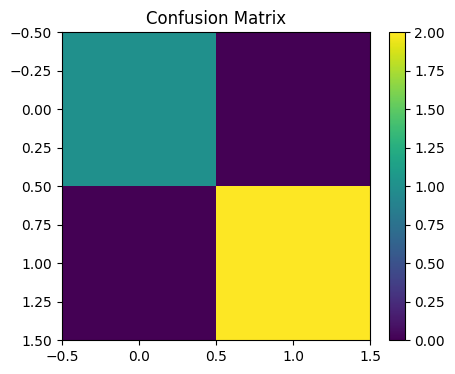

In [9]:
plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.colorbar()

plt.title(
    "Confusion Matrix"
)

plt.show()

# 3. Accuracy

In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

1.0


# Rumus Accuracy

\[
Accuracy=
\frac{TP+TN}{Total}
\]

# 4. Precision

In [11]:
precision = precision_score(
    y_test,
    y_pred
)

print(precision)

1.0


# Rumus Precision

\[
Precision=
\frac{TP}{TP+FP}
\]

# 5. Recall

In [12]:
recall = recall_score(
    y_test,
    y_pred
)

print(recall)

1.0


# Rumus Recall

\[
Recall=
\frac{TP}{TP+FN}
\]

# 6. F1 Score

In [13]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f1)

1.0


# Rumus F1 Score

\[
F1=
2
\times
\frac{Precision \times Recall}
{Precision + Recall}
\]

# Kapan F1 Score Digunakan?

F1 Score sangat berguna ketika dataset tidak seimbang (imbalanced dataset).

# 7. ROC Curve

ROC Curve membandingkan:

- True Positive Rate
- False Positive Rate

In [14]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob[:,1]
)

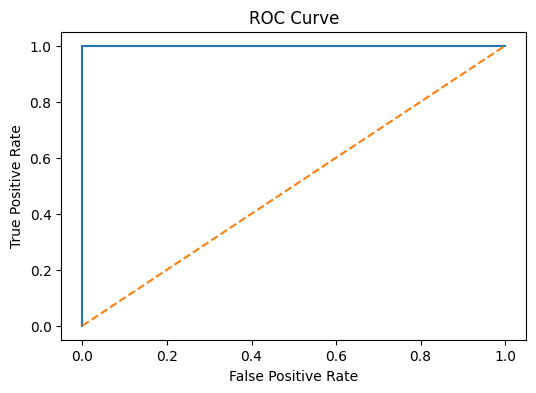

In [15]:
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Interpretasi ROC Curve

Semakin dekat ke kiri atas maka model semakin baik.

# 8. AUC

Area Under Curve (AUC) mengukur kualitas model klasifikasi.

In [16]:
auc = roc_auc_score(
    y_test,
    y_prob[:,1]
)

print(auc)

1.0


# Interpretasi AUC

- 0.5 = Random Guess
- 0.7 = Fair
- 0.8 = Good
- 0.9+ = Excellent

# 9. Naive Bayes

Naive Bayes adalah algoritma klasifikasi berbasis probabilitas.

In [17]:
nb_model = GaussianNB()

nb_model.fit(
    X_train,
    y_train
)

GaussianNB()

# Prediksi Naive Bayes

In [18]:
nb_pred = nb_model.predict(
    X_test
)

nb_pred

array([1, 1, 1])

In [19]:
nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print(nb_accuracy)

0.6666666666666666


# Perbandingan Model

In [20]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy":[
        accuracy,
        nb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.000000
1,Naive Bayes,0.666667


# Kelebihan Logistic Regression

- Mudah dipahami
- Cepat
- Cocok untuk klasifikasi biner

# Kelebihan Naive Bayes

- Sangat cepat
- Cocok untuk dataset besar
- Baik untuk klasifikasi teks

# Ringkasan Chapter 5

Pada chapter ini dipelajari:

- Logistic Regression
- Classification
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- ROC Curve
- AUC
- Naive Bayes

Classification digunakan untuk memprediksi kategori suatu data dan merupakan salah satu bidang terpenting dalam Machine Learning.